# Breast Cancer Classification

Student Name : **Sidra Bilal**

Student ID : **0626602**


##Description:

This project tackles the  classification of microcalcifications (MCs) in breast cancer data, distinguishing between benign and malignant cases. The dataset contains 150 features per sample, extracted from mammography images.

We apply multiple machine learning models and evaluate them at both the microcalcification level and patient level.


We will be training models both with and without hyperparameter tuning to compare the results


**Models used**:
- Logistic Regression
- Random Forest
- K-Nearest Neighbors (KNN)

We use 5-fold patient-wise cross-validation (GroupKFold) to ensure no patient's data appears in both training and testing sets. Model performance is reported using Accuracy and F1-score for both levels.

## Steps

**Step 1:** We will load the file containing all the data in Google Colab


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Reduced Features for TAI project.xlsx to Reduced Features for TAI project.xlsx


**Step 2:** Loading the data from excel file using pandas library and diaplaying the first few rows

In [4]:
import pandas as pd

# Read the excel file
df = pd.read_excel('Reduced Features for TAI project.xlsx')

# Show the first few rows
df.head()


,Patient ID,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet2-LHL_gldm_DependenceVariance,wavelet2-LHL_glrlm_RunVariance,...,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-HHH_firstorder_RootMeanSquared,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,wavelet2-LHH_firstorder_RootMeanSquared,wavelet2-HLL_firstorder_Maximum,Label
0,1,0.661690,2.817688,0.769536,7.257078,3381.734540,3715.077716,3546.818663,634.748331,6.682128,...,4005.210235,0.408974,2.949406,0.231474,0.473838,1.572473,0.983853,0.875074,142.866201,0
1,1,0.750849,2.084800,0.442780,3.137745,2653.808184,1443.697357,2297.305200,616.359443,4.095513,...,32.058217,0.282009,2.790798,0.010531,0.401979,1.178144,0.905124,0.696716,21.693040,0
2,1,0.619781,2.590759,0.384512,7.005413,3551.125894,3568.780890,3342.865490,426.661231,8.535867,...,63032.030205,0.442902,3.211156,0.276207,0.446076,1.615550,0.993054,0.832938,163.039718,0
3,2,0.388733,2.932863,0.738215,2.178815,1564.039548,1370.065913,1839.930320,318.122386,1.939531,...,147.649047,0.330143,3.054401,0.023870,0.399957,1.306885,0.911141,0.727764,22.979554,0
4,2,0.820531,2.814081,0.773252,1.316850,1377.981413,1005.602230,1164.799257,325.473446,1.726775,...,65.872763,0.278449,2.074076,0.016973,0.350459,1.165727,0.906515,0.606753,24.490320,0


**Step 3:** Get the information regarding data e.g number of entires, column, unique patients count and label distribution

In [7]:
# Check information
print(df.info())


# Count unique patients and labels
print("Unique patients:", df['Patient ID'].nunique())  # Adjust if column name differs
print("Label distribution:\n", df['Label'].value_counts())  # Adjust if column name differs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Columns: 152 entries, Patient ID to Label
dtypes: float64(150), int64(2)
memory usage: 4.1 MB
None

Unique patients: 96
Label distribution:
 Label
0    2020
1    1542
Name: count, dtype: int64


**Step 4: Feature and Label Separation** Dividing data into features and label. Spliting data into groups by patient

In [9]:
x = df.drop(['Patient ID', 'Label'], axis=1)  # Features
y = df['Label']                               # Labels
groups = df['Patient ID']                     # Groups
x.head()

,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet2-LHL_gldm_DependenceVariance,wavelet2-LHL_glrlm_RunVariance,wavelet-LHL_glrlm_LongRunEmphasis,...,wavelet-HHH_glrlm_LongRunHighGrayLevelEmphasis,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-HHH_firstorder_RootMeanSquared,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,wavelet2-LHH_firstorder_RootMeanSquared,wavelet2-HLL_firstorder_Maximum
0,0.661690,2.817688,0.769536,7.257078,3381.734540,3715.077716,3546.818663,634.748331,6.682128,16.208843,...,13.110078,4005.210235,0.408974,2.949406,0.231474,0.473838,1.572473,0.983853,0.875074,142.866201
1,0.750849,2.084800,0.442780,3.137745,2653.808184,1443.697357,2297.305200,616.359443,4.095513,8.438487,...,10.093049,32.058217,0.282009,2.790798,0.010531,0.401979,1.178144,0.905124,0.696716,21.693040
2,0.619781,2.590759,0.384512,7.005413,3551.125894,3568.780890,3342.865490,426.661231,8.535867,15.858577,...,15.769474,63032.030205,0.442902,3.211156,0.276207,0.446076,1.615550,0.993054,0.832938,163.039718
3,0.388733,2.932863,0.738215,2.178815,1564.039548,1370.065913,1839.930320,318.122386,1.939531,7.685345,...,8.035637,147.649047,0.330143,3.054401,0.023870,0.399957,1.306885,0.911141,0.727764,22.979554
4,0.820531,2.814081,0.773252,1.316850,1377.981413,1005.602230,1164.799257,325.473446,1.726775,4.956038,...,7.530571,65.872763,0.278449,2.074076,0.016973,0.350459,1.165727,0.906515,0.606753,24.490320


**Step 5: Missing Data Checks** Looking for any missing data

In [11]:
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 Patient ID                                 0
original_shape_Elongation                  0
original_firstorder_Kurtosis               0
original_firstorder_Skewness               0
wavelet-LHL_glrlm_RunVariance              0
                                          ..
original_shape_SphericalDisproportion      0
wavelet2-HHL_glcm_Idmn                     0
wavelet2-LHH_firstorder_RootMeanSquared    0
wavelet2-HLL_firstorder_Maximum            0
Label                                      0
Length: 152, dtype: int64


**Step 6: Data Visualization and Analysis** Display how data is distributed using matplot library


1. Label Distribution

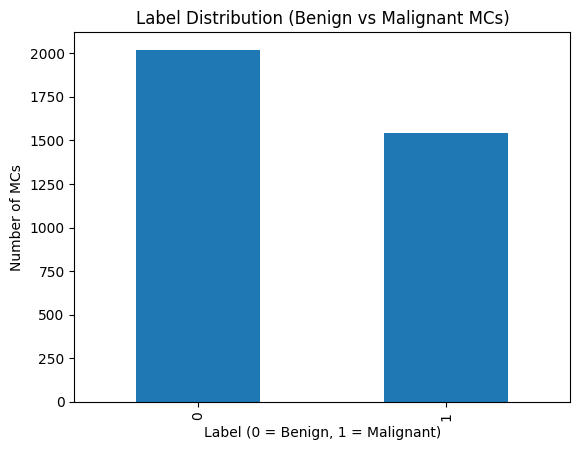

In [10]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title('Label Distribution (Benign vs Malignant MCs)')
plt.xlabel('Label (0 = Benign, 1 = Malignant)')
plt.ylabel('Number of MCs')
plt.show()


2. Patient Distribution

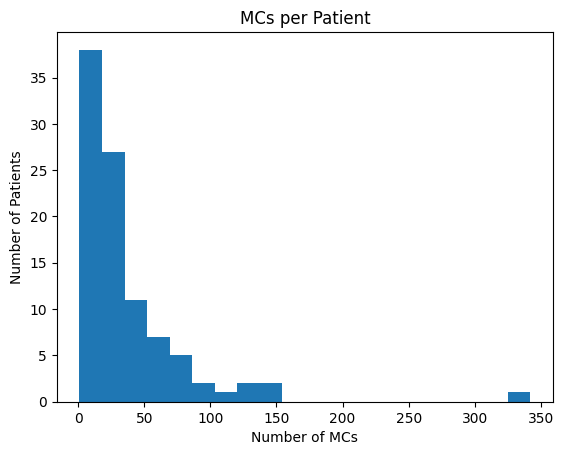

In [11]:
df['Patient ID'].value_counts().plot(kind='hist', bins=20)
plt.title('MCs per Patient')
plt.xlabel('Number of MCs')
plt.ylabel('Number of Patients')
plt.show()


3. Feature Distribution

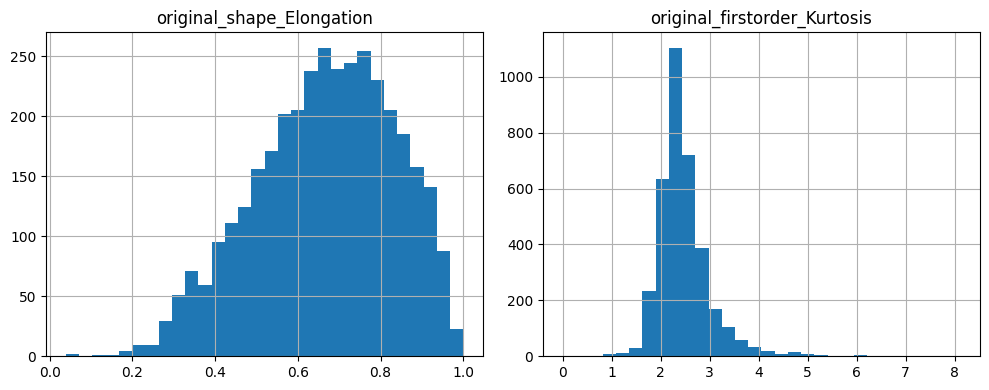

In [12]:
feature_cols = ['original_shape_Elongation', 'original_firstorder_Kurtosis']
df[feature_cols].hist(bins=30, figsize=(10, 4))
plt.tight_layout()
plt.show()


4. Feature Correlation for the first 10 features

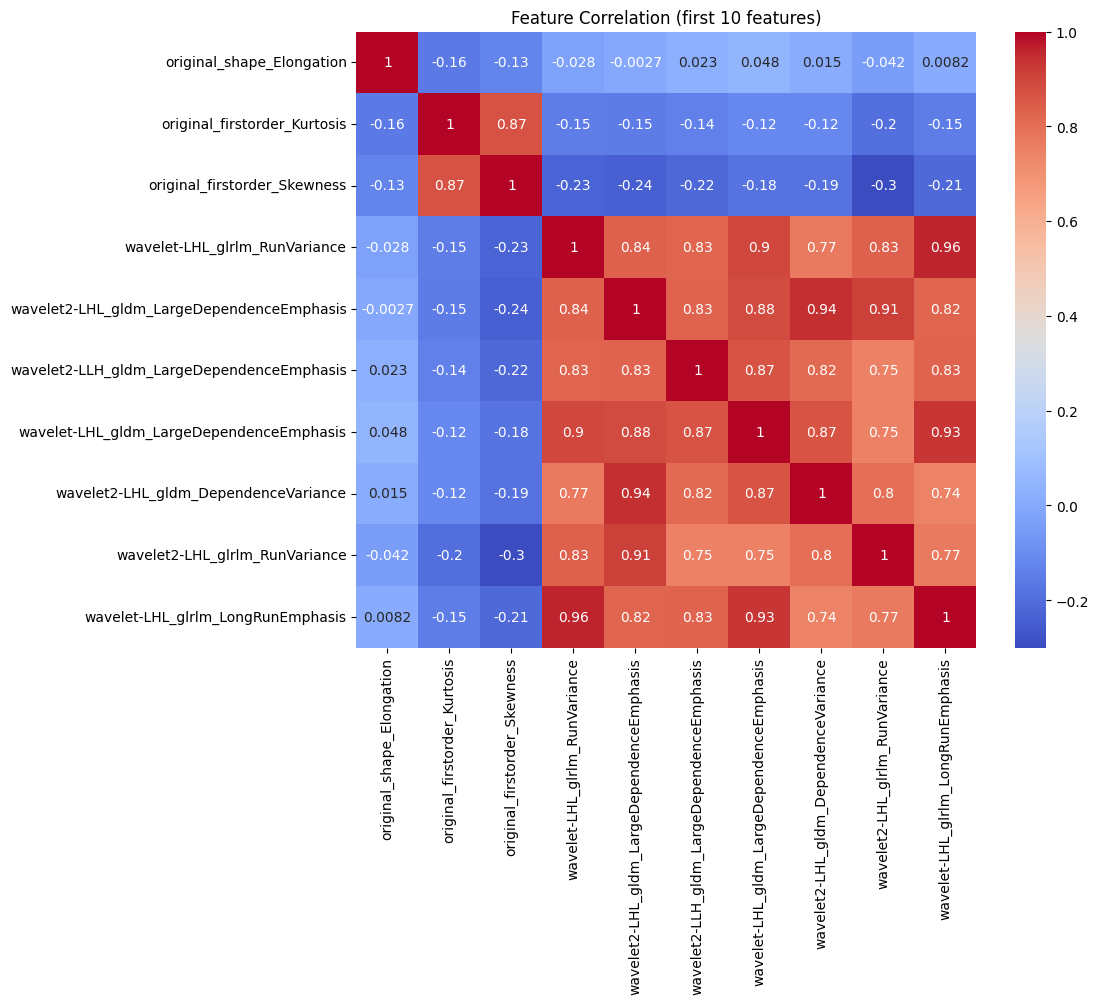

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, 1:11].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


5. Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Features shape:", x_scaled.shape)
print("Labels shape:", y.shape)
print("Number of unique patients:", groups.nunique())


**Step 7: Grouping Patient Data** Making sure all MCs from the same patient are only in train or test set, never both by using GroupKFold which splits the data by group (patient), so each fold contains unique patients.

In [20]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)  # 5-fold cross-validation


**Step 8: Train and Evaluate Models without hyperparameter tuning**
1. We'll loop through each split and
2. Train models on the training patients.
3. Test it on the unseen patients in the test set.
4. Collect and print accuracy and F1-score.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score


rf_acc, rf_f1 = [], []
lr_acc, lr_f1 = [], []
xgb_acc, xgb_f1 = [], []
knn_acc, knn_f1 = [], []



for train_idx, test_idx in gkf.split(x_scaled, y, groups):
    X_train, X_test = x_scaled[train_idx], x_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_acc.append(accuracy_score(y_test, y_pred_rf))
    rf_f1.append(f1_score(y_test, y_pred_rf))



    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    lr_acc.append(accuracy_score(y_test, y_pred_lr))
    lr_f1.append(f1_score(y_test, y_pred_lr))

    # K-Nearest Neighbors
    knn = KNeighborsClassifier(n_neighbors=5)  # 5 is a common default, can tune later
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    knn_acc.append(accuracy_score(y_test, y_pred_knn))
    knn_f1.append(f1_score(y_test, y_pred_knn))


print(f"Random Forest      - Mean accuracy: {sum(rf_acc)/len(rf_acc):.3f} | Mean F1-score: {sum(rf_f1)/len(rf_f1):.3f}")
print(f"LogisticRegression - Mean accuracy: {sum(lr_acc)/len(lr_acc):.3f} | Mean F1-score: {sum(lr_f1)/len(lr_f1):.3f}")
print(f"KNN                - Mean accuracy: {sum(knn_acc)/len(knn_acc):.3f} | Mean F1-score: {sum(knn_f1)/len(knn_f1):.3f}")


Random Forest      - Mean accuracy: 0.746 | Mean F1-score: 0.652
LogisticRegression - Mean accuracy: 0.731 | Mean F1-score: 0.649
KNN                - Mean accuracy: 0.685 | Mean F1-score: 0.587


**Step 9: Train and Evaluate Models with hyperparameter tuning**
1. Define hyperparameter grids for all 3 models
2. Train models using GridSearchCV.
3. Test it on the unseen patients in the test set.
4. Collect and print accuracy and F1-score.

In [25]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score


# Define hyperparameter grids
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']}
param_grid_knn = {'n_neighbors': [3, 5, 7, 9]}

# Lists to store metrics
rf_acc, rf_f1_tuned = [], []
lr_acc, lr_f1_tuned = [], []
knn_acc, knn_f1_tuned= [], []

# Cross-validation loop
for train_idx, test_idx in gkf.split(x_scaled, y, groups):
    X_train, X_test = x_scaled[train_idx], x_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Random Forest with GridSearch
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='f1')
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    rf_acc.append(accuracy_score(y_test, y_pred_rf))
    rf_f1_tuned.append(f1_score(y_test, y_pred_rf))

    # Logistic Regression with GridSearch
    grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3, scoring='f1')
    grid_lr.fit(X_train, y_train)
    best_lr = grid_lr.best_estimator_
    y_pred_lr = best_lr.predict(X_test)
    lr_acc.append(accuracy_score(y_test, y_pred_lr))
    lr_f1_tuned.append(f1_score(y_test, y_pred_lr))

    # KNN with GridSearch
    grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='f1')
    grid_knn.fit(X_train, y_train)
    best_knn = grid_knn.best_estimator_
    y_pred_knn = best_knn.predict(X_test)
    knn_acc.append(accuracy_score(y_test, y_pred_knn))
    knn_f1_tuned.append(f1_score(y_test, y_pred_knn))

# Display mean accuracy and F1 scores
print(f"Random Forest       - Mean accuracy: {sum(rf_acc)/len(rf_acc):.3f} | Mean F1-score: {sum(rf_f1_tuned)/len(rf_acc):.3f}")
print(f"Logistic Regression - Mean accuracy: {sum(lr_acc)/len(rf_acc):.3f} | Mean F1-score: {sum(lr_f1_tuned)/len(rf_acc):.3f}")
print(f"KNN                 - Mean accuracy: {sum(knn_acc)/len(rf_acc):.3f} | Mean F1-score: {sum(knn_f1_tuned)/len(rf_acc):.3f}")


Random Forest       - Mean accuracy: 0.751 | Mean F1-score: 0.658
Logistic Regression - Mean accuracy: 0.734 | Mean F1-score: 0.651
KNN                 - Mean accuracy: 0.678 | Mean F1-score: 0.586


**Step 9: Comparison beteween Models with and without hyperparameter tuning**

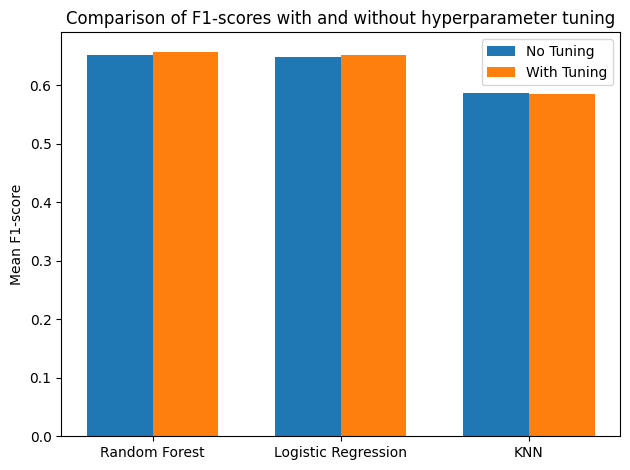

In [27]:
import matplotlib.pyplot as plt
import numpy as np
# Plotting the comparison
labels = ['Random Forest', 'Logistic Regression', 'KNN']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, [np.mean(rf_f1), np.mean(lr_f1), np.mean(knn_f1)], width, label='No Tuning')
rects2 = ax.bar(x + width/2, [np.mean(rf_f1_tuned), np.mean(lr_f1_tuned), np.mean(knn_f1_tuned)], width, label='With Tuning')

# Add some text for labels, title, and axes ticks
ax.set_ylabel('Mean F1-score')
ax.set_title('Comparison of F1-scores with and without hyperparameter tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()

**Step 10: Patient Level Aggregation and Evaluation**
Instead of classifying each microcalcification (MC) individually, we want to predict whether each patient has cancer or not, based on the predictions for all their MCs.

**Please note: Generative AI was used for some part of this code**

In [31]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict
import numpy as np

# Store results for each model
results = {
    'rf': {'micro_acc': [], 'micro_f1': [], 'patient_acc': [], 'patient_f1': []},
    'lr': {'micro_acc': [], 'micro_f1': [], 'patient_acc': [], 'patient_f1': []},
    'knn': {'micro_acc': [], 'micro_f1': [], 'patient_acc': [], 'patient_f1': []}
}

for train_idx, test_idx in gkf.split(x_scaled, y, groups):
    X_train, X_test = x_scaled[train_idx], x_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_patient_ids = groups.iloc[test_idx].values

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    results['rf']['micro_acc'].append(accuracy_score(y_test, y_pred_rf))
    results['rf']['micro_f1'].append(f1_score(y_test, y_pred_rf))

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    results['lr']['micro_acc'].append(accuracy_score(y_test, y_pred_lr))
    results['lr']['micro_f1'].append(f1_score(y_test, y_pred_lr))

    # KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    results['knn']['micro_acc'].append(accuracy_score(y_test, y_pred_knn))
    results['knn']['micro_f1'].append(f1_score(y_test, y_pred_knn))

    # ---- Patient-level aggregation for each model ----
    for model_key, y_pred in zip(['rf', 'lr', 'knn'],
                                 [y_pred_rf, y_pred_lr, y_pred_knn]):
        # Aggregate predictions for each patient
        patient_preds = defaultdict(list)
        patient_trues = {}

        for pid, true, pred in zip(test_patient_ids, y_test, y_pred):
            patient_preds[pid].append(pred)
            patient_trues[pid] = true

        final_preds = []
        final_trues = []

        for pid in patient_preds:
            votes = patient_preds[pid]
            pred_label = int(np.round(np.mean(votes)))  # Majority vote
            final_preds.append(pred_label)
            final_trues.append(patient_trues[pid])

        results[model_key]['patient_acc'].append(accuracy_score(final_trues, final_preds))
        results[model_key]['patient_f1'].append(f1_score(final_trues, final_preds))

# Print average micro and patient-level results
for model_key, model_name in zip(['rf', 'lr', 'knn'],
                                 ['Random Forest', 'Logistic Regression', 'KNN']):
    print(f'{model_name} - Micro Accuracy: {np.mean(results[model_key]["micro_acc"]):.3f}, '
          f'Micro F1: {np.mean(results[model_key]["micro_f1"]):.3f} | '
          f'Patient Accuracy: {np.mean(results[model_key]["patient_acc"]):.3f}, '
          f'Patient F1: {np.mean(results[model_key]["patient_f1"]):.3f}')


Random Forest - Micro Accuracy: 0.746, Micro F1: 0.652 | Patient Accuracy: 0.737, Patient F1: 0.691
Logistic Regression - Micro Accuracy: 0.731, Micro F1: 0.649 | Patient Accuracy: 0.777, Patient F1: 0.748
KNN - Micro Accuracy: 0.685, Micro F1: 0.587 | Patient Accuracy: 0.718, Patient F1: 0.677


**Step 10: Result visualization**

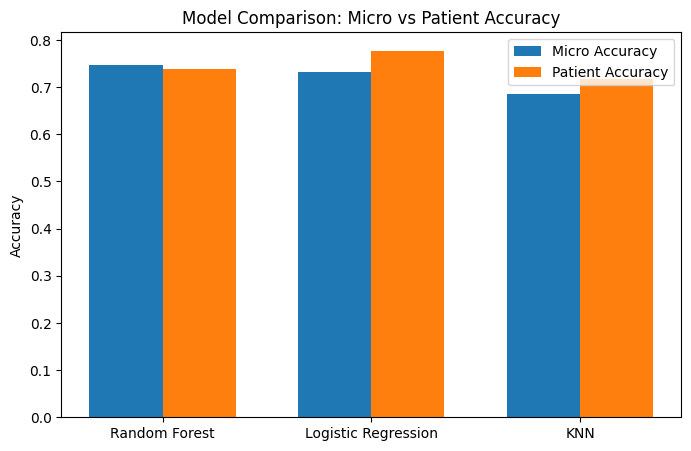

In [32]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Random Forest', 'Logistic Regression', 'KNN']
micro_acc = [np.mean(results['rf']['micro_acc']), np.mean(results['lr']['micro_acc']), np.mean(results['knn']['micro_acc'])]
patient_acc = [np.mean(results['rf']['patient_acc']), np.mean(results['lr']['patient_acc']), np.mean(results['knn']['patient_acc'])]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, micro_acc, width, label='Micro Accuracy')
rects2 = ax.bar(x + width/2, patient_acc, width, label='Patient Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Micro vs Patient Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.show()


## Conclusion

* **Logistic Regression** achieves the highest patient-level accuracy (0.777) and F1-score (0.748), despite slightly lower performance compared to Random Forest.

* **Random Forest** shows strong performance (accuracy = 0.746, F1 = 0.652) and good patient-level results, indicating that while it can classify individual MCs well, its patient-level decisions may be less stable when aggregating.

* **KNN** performs the worst among all models on both micro and patient levels.


### Please Note:
Unless specified, Generative AI was used only for code structuring or documentation suggestions, not for final implementation.
